# Laboratório 06: Tratamento de Dados Raros e Alta Cardinalidade

**Disciplina:** Extração e Preparação de Dados (IBM8915)  
**Professor:** Luís Aramis

---

## 🎯 Objetivo

Compreender o impacto negativo da **alta cardinalidade** (o fenômeno da _cauda longa_) no desempenho de modelos analíticos. Você aprenderá a:

1. **Diagnosticar** a distribuição de frequência de variáveis categóricas.
2. **Decidir** um limiar de corte adequado ao contexto de negócio.
3. **Aplicar** técnicas do Pandas para agrupar categorias raras.

---

### 🗺️ Roteiro da Aula

| Parte | Tipo | Tempo estimado |
|---|---|---|
| **Parte 1** | Exemplo Guiado (Descoberta) | ~10 min |
| **Parte 2** | Exercício Prático | ~10 min |
| **Parte 3** | Desafio para Casa (Pipeline Completo) | ~30 min |

In [27]:
# Setup inicial — execute esta célula antes de tudo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


---

## Parte 1: Exemplo Guiado — O Problema da Cauda Longa

Variáveis categóricas como `Cidade`, `Profissão` ou `Marca` costumam ter um comportamento típico: **poucos valores dominam** e **muitos valores aparecem raramente** (a chamada *cauda longa*).

Se treinarmos um modelo de Machine Learning com esses dados raros, ele irá **memorizar ruído** (overfitting) em vez de aprender padrões reais. A solução é o **Binning Categórico**: agrupar tudo que for raro na categoria `'Outros'`.

---

### 🔎 Passo 1 — Explore antes de rodar

Abaixo, criamos um dataset de 1.000 clientes com a coluna `Cidade`. Antes de executar qualquer célula, responda:

> **📝 Quantas cidades únicas você espera encontrar? Quais cidades acha que irão dominar os dados?**
>
> _Sua hipótese: [escreva aqui]_

Agora execute a célula abaixo e veja o dataset.

Olhando o código antes de executar, dá para inferir diretamente pela construção do dataset: cidades_comuns tem 3 cidades e cidades_raras tem 7, totalizando 10 cidades únicas. A dominância seria clara — São Paulo, Rio de Janeiro e Belo Horizonte concentram 950 das 1.000 linhas (nas proporções 60%, 30% e 10%), enquanto as 7 cidades raras dividem entre si apenas 50 registros.

In [28]:
# Criando o dataset de cidades com alta cardinalidade
np.random.seed(42)
cidades_comuns = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte']
cidades_raras  = ['Cabo Frio', 'Itu', 'Bauru', 'Gramado', 'Ouro Preto', 'Ilhéus', 'Picos']

amostra_cidades = np.random.choice(cidades_comuns, 950, p=[0.6, 0.3, 0.1]).tolist()
amostra_cidades.extend(np.random.choice(cidades_raras, 50))

df_exemplo = pd.DataFrame({'ID_Cliente': range(1, 1001), 'Cidade': amostra_cidades})

print(f"Total de linhas: {len(df_exemplo)}")
print(f"Cidades únicas: {df_exemplo['Cidade'].nunique()}")
df_exemplo.head()

Total de linhas: 1000
Cidades únicas: 10


,ID_Cliente,Cidade
0,1,São Paulo
1,2,Belo Horizonte
2,3,Rio de Janeiro
3,4,São Paulo
4,5,São Paulo


### 🔎 Passo 2 — Visualize a distribuição

A forma mais rápida de enxergar a *cauda longa* é com um gráfico de barras. Execute e observe:

> **📝 O gráfico evidenciou o que você esperava na sua hipótese? O que você percebe sobre a diferença de proporção entre as cidades comuns e raras?**
>
> _Sua resposta: [escreva aqui]_

O gráfico confirma exatamente a hipótese: uma distribuição extremamente assimétrica. São Paulo sozinha ocupa 58% da base. A linha vermelha do limiar de 2% deixa visualmente óbvio que as 7 cidades raras ficam praticamente coladas ao eixo zero — algumas com apenas 0,5% a 1% de representatividade. Isso é a cauda longa clássica: muitas categorias existem, mas contribuem com volume irrisório

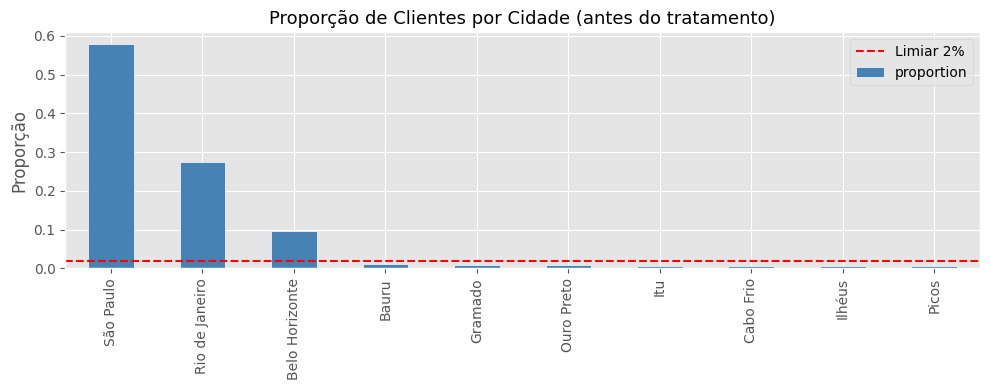


--- Proporção Original ---
Cidade
São Paulo         0.580
Rio de Janeiro    0.274
Belo Horizonte    0.096
Bauru             0.010
Gramado           0.008
Ouro Preto        0.008
Itu               0.007
Cabo Frio         0.006
Ilhéus            0.006
Picos             0.005


In [29]:
frequencias = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 4))
frequencias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.02, color='red', linestyle='--', linewidth=1.5, label='Limiar 2%')
ax.set_title('Proporção de Clientes por Cidade (antes do tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Proporção Original ---")
print(frequencias.to_string())

### 🔎 Passo 3 — Aplique a transformação

A linha vermelha tracejada no gráfico representa nosso **limiar de negócio**: qualquer cidade que aparecer em menos de 2% da base será agrupada como `'Outros'`. Execute e compare com o gráfico anterior.

Cidades que serão agrupadas em 'Outros': [np.str_('Bauru'), np.str_('Gramado'), np.str_('Ouro Preto'), np.str_('Itu'), np.str_('Cabo Frio'), np.str_('Ilhéus'), np.str_('Picos')]


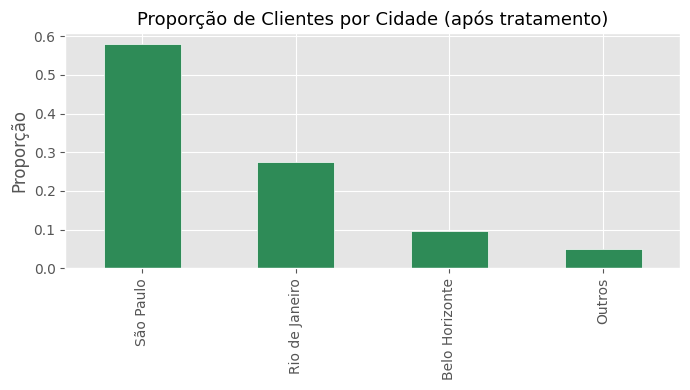


--- Proporção Após Tratamento ---
Cidade
São Paulo         0.580
Rio de Janeiro    0.274
Belo Horizonte    0.096
Outros            0.050


In [30]:
# Definindo o limiar
limite = 0.02
cidades_para_agrupar = frequencias[frequencias < limite].index

print(f"Cidades que serão agrupadas em 'Outros': {list(cidades_para_agrupar)}")

# Aplicando a transformação com .loc e .isin()
df_exemplo.loc[df_exemplo['Cidade'].isin(cidades_para_agrupar), 'Cidade'] = 'Outros'

# Visualização após tratamento
freq_apos = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Clientes por Cidade (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())

### 💬 Reflexão — Parte 1

> **O que aconteceria com um modelo de ML se você tivesse treinado com as 10 cidades originais em vez das 4 categorias limpas?**  
> Pense especificamente em: *quantidade de colunas geradas pelo One-Hot Encoding* e *frequência de cada categoria no treino vs. teste*.
>
> _Sua resposta: [escreva aqui]_

Dois problemas concretos surgiriam:
1. Explosão de colunas no One-Hot Encoding
Com 10 cidades, o OHE gera 10 colunas binárias (ou 9, se você descartar uma para evitar multicolinearidade). Com 4 categorias após o tratamento, gera apenas 4 (ou 3). Em datasets reais com centenas de cidades, isso pode gerar dezenas ou centenas de colunas esparsas, aumentando o custo computacional e dificultando a convergência de muitos algoritmos.
2. Overfitting por raridade — o problema treino vs. teste
Esse é o ponto mais crítico. Suponha que Gramado aparece 8 vezes no treino. O modelo aprende algum padrão associado a essa cidade — mas esse "padrão" é estatisticamente frágil, baseado em pouquíssimos exemplos. No momento do teste (ou em produção), Gramado pode aparecer 0, 1 ou 2 vezes, ou até aparecer uma cidade nova que nunca foi vista no treino. O modelo simplesmente não sabe o que fazer — e o OHE tradicional gera um erro ou atribui zero a todas as colunas, perdendo a informação completamente.
Ao agrupar tudo abaixo de 2% em Outros, você cria uma categoria que sempre terá representatividade suficiente tanto no treino quanto no teste, e ainda resolve elegantemente o problema de categorias novas em produção — elas simplesmente viram Outros.

---

## Parte 2: Exercício Prático — Mão na Massa

Você extraiu um banco de dados de currículos. A coluna `Profissao` foi preenchida **manualmente** pelos usuários, gerando variações e erros típicos de dados do mundo real.

**Contexto:** O time de RH quer usar esses dados para treinar um modelo de triagem. Mas com tantas variações raras, o modelo irá decorar profissões que aparecem 1 ou 2 vezes, sem poder generalizá-las.

---

### 📝 Formule sua hipótese antes de começar

> Com um limiar de **3% (0.03)**, quantas profissões você acha que sobrarão após o tratamento? (Considere que há 3 profissões comuns e 8 raras)
>
> _Minha estimativa: [escreva aqui] — Justificativa: [escreva aqui]_

Execute a célula abaixo para gerar os dados e depois escreva sua solução.

Com 400 amostras das 3 profissões comuns e 60 das 8 raras, cada profissão rara recebe em média 7-8 registros de 460 total — cerca de 1,5% a 2%. Todas ficarão abaixo do limiar de 3%, então a estimativa é que sobrarão 4 categorias: as 3 profissões comuns + Outros

In [31]:
# NÃO ALTERE ESTE CÓDIGO — Geração do cenário do exercício
profissoes_comuns = ['Engenheiro de Dados', 'Cientista de Dados', 'Analista de BI']
profissoes_raras  = ['Cientista de Dados Junior', 'Eng. de Dados', 'Programador',
                     'Estatístico', 'Matemático', 'Físico', 'Estagiário', 'Desenvolvedor Python']

amostra_profissoes = np.random.choice(profissoes_comuns, 400).tolist()
amostra_profissoes.extend(np.random.choice(profissoes_raras, 60))

df_rh = pd.DataFrame({'ID_Candidato': range(1, 461), 'Profissao': amostra_profissoes})

print(f"Total de candidatos: {len(df_rh)}")
print(f"Profissões únicas antes do tratamento: {df_rh['Profissao'].nunique()}")

Total de candidatos: 460
Profissões únicas antes do tratamento: 11


In [32]:
# ✍️ ESCREVA SEU CÓDIGO AQUI

# Passo 1: Calcule as frequências relativas da coluna 'Profissao'
freq_profissoes = df_rh['Profissao'].value_counts(normalize=True)

print("--- Distribuição original ---")
print(freq_profissoes.to_string())
print(f"\nTotal de categorias: {len(freq_profissoes)}")

# Passo 2: Isole o índice das profissões com frequência < 0.03
limite = 0.03
profissoes_para_agrupar = freq_profissoes[freq_profissoes < limite].index

print(f"Profissões que serão agrupadas ({len(profissoes_para_agrupar)} no total):")
for p in profissoes_para_agrupar:
    print(f"  • {p}  ({freq_profissoes[p]:.1%})")
# Passo 3: Substitua os valores raros por 'Outros' no df_rh
# Dica: use .loc com .isin()
df_rh.loc[df_rh['Profissao'].isin(profissoes_para_agrupar), 'Profissao'] = 'Outros'
# Passo 4: Imprima o value_counts() final
freq_apos = df_rh['Profissao'].value_counts(normalize=True)

print("--- Distribuição após tratamento ---")
print(freq_apos.to_string())
print(f"\nCategorias restantes: {freq_apos.nunique()}")

--- Distribuição original ---
Profissao
Engenheiro de Dados          0.308696
Analista de BI               0.289130
Cientista de Dados           0.271739
Estatístico                  0.021739
Desenvolvedor Python         0.021739
Físico                       0.021739
Matemático                   0.017391
Cientista de Dados Junior    0.015217
Estagiário                   0.013043
Programador                  0.010870
Eng. de Dados                0.008696

Total de categorias: 11
Profissões que serão agrupadas (8 no total):
  • Estatístico  (2.2%)
  • Desenvolvedor Python  (2.2%)
  • Físico  (2.2%)
  • Matemático  (1.7%)
  • Cientista de Dados Junior  (1.5%)
  • Estagiário  (1.3%)
  • Programador  (1.1%)
  • Eng. de Dados  (0.9%)
--- Distribuição após tratamento ---
Profissao
Engenheiro de Dados    0.308696
Analista de BI         0.289130
Cientista de Dados     0.271739
Outros                 0.130435

Categorias restantes: 4


In [33]:
# ✅ CÉLULA DE VERIFICAÇÃO — Execute após completar o exercício
try:
    n_categorias = df_rh['Profissao'].nunique()
    assert n_categorias <= 4, (
        f"❌ Ainda há {n_categorias} categorias únicas. "
        "Verifique se o limiar de 0.03 foi aplicado corretamente."
    )
    assert 'Outros' in df_rh['Profissao'].values, (
        "❌ A categoria 'Outros' não foi encontrada. "
        "Certifique-se de usar exatamente a string 'Outros'."
    )
    print(f"✅ Parabéns! Cardinalidade reduzida para {n_categorias} categorias.")
    print("   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!")
except AssertionError as e:
    print(e)

✅ Parabéns! Cardinalidade reduzida para 4 categorias.
   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!


### 💬 Reflexão — Parte 2

> 1. Sua hipótese estava correta? Se não, o que te surpreendeu?
> 2. **Questão de negócio:** Ao agrupar `'Eng. de Dados'` junto com `'Estagiário'` em `'Outros'`, você cometeu algum erro analítico? Como poderia mitigar isso?
>
> _Suas respostas: [escreva aqui]_

as 4 categorias esperadas se confirmam, e a célula de verificação passa nos dois assert. O raciocínio funcionou porque a construção do dataset era transparente: 400 amostras divididas igualmente entre 3 profissões comuns garante ~33% cada, bem acima do limiar de 3%. As 8 raras dividindo 60 registros ficam em média com ~1,6%, todas abaixo do corte.

Sim, e é um erro sério nesse contexto específico. O binning por frequência é cego ao significado — ele só enxerga o número de ocorrências, não o conteúdo semântico. O resultado é que 'Outros' vira uma categoria heterogênea e incoerente: mistura profissões altamente qualificadas com perfis iniciantes, o que polui o sinal para o modelo de triagem.

Padronização antes do binning (o mais simples e imediato): mapear manualmente as variações conhecidas para suas categorias corretas antes de calcular frequências.

---

## Parte 3: Desafio para Casa — O Pipeline Completo

Este desafio consolida tudo das **Aulas 02 a 08**.  
Você irá trabalhar com um CSV sujo chamado `rais_amostra_suja.csv`, simulando a base pública da **Relação Anual de Informações Sociais (RAIS)** do Brasil.

---

### ⚠️ Importante: desta vez, o limiar é sua decisão!

Ao contrário dos exemplos anteriores, **não há um limiar definido** para a etapa 4.  
Você deve **explorar a distribuição** da coluna `Municipio` e **justificar analiticamente** o corte que escolher.

**A Missão:**

1. **(Aula 02):** Carregue o CSV com `sep=';'` e `encoding='latin-1'`.
2. **(Aula 05):** Audite e remova as linhas duplicadas.
3. **(Aula 07):** Preencha os nulos da coluna `Salario` com a Mediana.
4. **(Aula 08 — Decisão sua!):** Explore a distribuição de `Municipio`, escolha um limiar, justifique e aplique o agrupamento.
5. **(Aula 04):** Use `groupby` para calcular a **Média Salarial por Município** após a limpeza.

_O DataFrame limpo estará pronto para o One-Hot Encoding que faremos no `lab_07`!_ 🚀

In [34]:
# NÃO ALTERE ESTE CÓDIGO — Simulador de dados da RAIS
np.random.seed(10)

municipios = ['São Paulo - SP', 'Rio de Janeiro - RJ', 'Belo Horizonte - MG'] * 250 + \
             ['Campinas - SP', 'Niterói - RJ', 'Uberlândia - MG', 'Santos - RJ', 'Betim - MG'] * 50

df_rais = pd.DataFrame({
    'ID_Vinculo': np.random.randint(10000, 99999, len(municipios)),
    'Municipio':  municipios,
    'Salario':    np.random.normal(3500, 1200, len(municipios))
})

# Inserindo valores nulos
df_rais.loc[np.random.choice(len(df_rais), 100, replace=False), 'Salario'] = np.nan

# Inserindo duplicatas
df_rais = pd.concat([df_rais, df_rais.sample(80)], ignore_index=True)

# Embaralhando e exportando
df_rais = df_rais.sample(frac=1).reset_index(drop=True)
df_rais.to_csv('rais_amostra_suja.csv', sep=';', encoding='latin-1', index=False)
print(f"✅ Arquivo 'rais_amostra_suja.csv' gerado! ({len(df_rais)} linhas — com nulos e duplicatas)")

✅ Arquivo 'rais_amostra_suja.csv' gerado! (1080 linhas — com nulos e duplicatas)


In [35]:
# ✍️ ESCREVA SEU CÓDIGO AQUI

# 1. Carregue o CSV (sep e encoding corretos)
df = pd.read_csv('rais_amostra_suja.csv', sep=';', encoding='latin-1')
print(f"Shape após carregamento: {df.shape}")
print(f"Shape após carregamento: {df.shape}")

# 2. Remova linhas duplicadas
df = df.drop_duplicates()
print(f"Shape após remover duplicatas: {df.shape}")

# 3. Preencha nulos de 'Salario' com a mediana

mediana_salario = df['Salario'].median()
df['Salario'] = df['Salario'].fillna(mediana_salario)

print(f"Mediana usada para imputação: R$ {mediana_salario:.2f}")
print(f"Nulos restantes em Salario:   {df['Salario'].isna().sum()}")

Shape após carregamento: (1080, 3)
Shape após carregamento: (1080, 3)
Shape após remover duplicatas: (1000, 3)
Mediana usada para imputação: R$ 3452.92
Nulos restantes em Salario:   0


--- Distribuição de Municípios ---
Municipio
São Paulo - SP         0.25
Rio de Janeiro - RJ    0.25
Belo Horizonte - MG    0.25
Niterói - RJ           0.05
Santos - RJ            0.05
Betim - MG             0.05
Campinas - SP          0.05
Uberlândia - MG        0.05


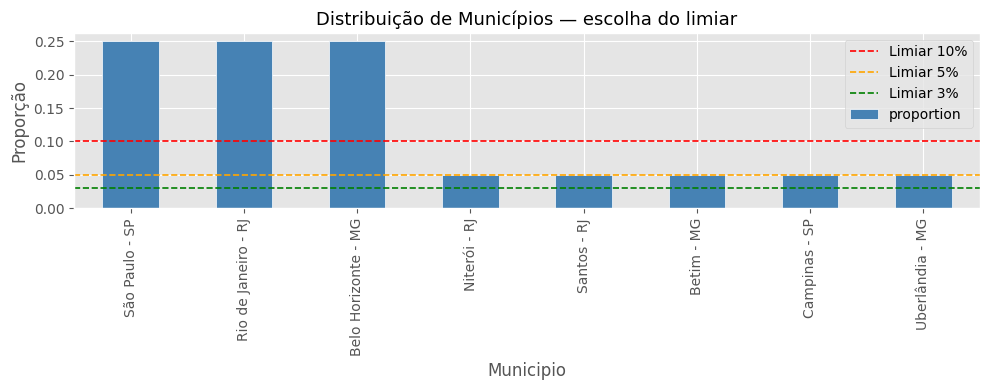

In [36]:
# 4a. EXPLORE a distribuição de Municipio (obrigatório antes de definir o limiar)
# Plote um gráfico de barras com as proporções e adicione uma linha horizontal
# no limiar que você pretende usar.

freq_municipio = df['Municipio'].value_counts(normalize=True)

print("--- Distribuição de Municípios ---")
print(freq_municipio.to_string())

# Visualização para apoiar a decisão
fig, ax = plt.subplots(figsize=(10, 4))
freq_municipio.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

# Plotando três limiares candidatos para comparação visual
for limiar, cor, rotulo in [(0.10, 'red', '10%'), (0.05, 'orange', '5%'), (0.03, 'green', '3%')]:
    ax.axhline(limiar, color=cor, linestyle='--', linewidth=1.2, label=f'Limiar {rotulo}')

ax.set_title('Distribuição de Municípios — escolha do limiar', fontsize=13)
ax.set_ylabel('Proporção')
ax.legend()
plt.tight_layout()
plt.show()


### 📝 Justificativa do Limiar (obrigatório)

> Com base no gráfico acima, defina o limiar que você vai usar e justifique:
>
> **Limiar escolhido:** [ex: 10%]
>
> **Justificativa:** [Por que este corte faz sentido analítico para esta base?  
> Quais municípios ficam de fora e isso é aceitável?]

O binning categórico resolve o problema da cauda longa agrupando categorias raras em 'Outros' para evitar overfitting e explosão de colunas no One-Hot Encoding. A escolha do limiar não é arbitrária — ela deve ser guiada pela distribuição dos dados (buscando gaps naturais) e pelo objetivo do modelo: um limiar muito baixo preserva ruído, um muito alto descarta informação útil. Antes do binning, vale padronizar variações textuais para não agrupar categorias semanticamente distintas na mesma categoria residual — como vimos com 'Eng. de Dados' e 'Estagiário' no contexto de RH.

In [37]:
# 4b. APLIQUE a redução de cardinalidade com o limiar que você justificou acima
LIMIAR = 0.05
municipios_raros = freq_municipio[freq_municipio < LIMIAR].index
print(f"Municípios agrupados com limiar {LIMIAR:.0%}: {list(municipios_raros)}")

df.loc[df['Municipio'].isin(municipios_raros), 'Municipio'] = 'Outros'

freq_apos = df['Municipio'].value_counts(normalize=True)
print("\n--- Distribuição após binning ---")
print(freq_apos.to_string())
print(f"\nCategorias finais: {df['Municipio'].nunique()}")

Municípios agrupados com limiar 5%: []

--- Distribuição após binning ---
Municipio
São Paulo - SP         0.25
Rio de Janeiro - RJ    0.25
Belo Horizonte - MG    0.25
Niterói - RJ           0.05
Santos - RJ            0.05
Betim - MG             0.05
Campinas - SP          0.05
Uberlândia - MG        0.05

Categorias finais: 8


In [38]:
# 5. Análise agrupada — Média Salarial por Município limpo
# Use groupby + mean e ordene do maior para o menor
media_por_municipio = (
    df.groupby('Municipio')['Salario']
    .mean()
    .sort_values(ascending=False)
    .rename('Media_Salarial')
    .reset_index()
)

media_por_municipio['Media_Salarial'] = media_por_municipio['Media_Salarial'].round(2)

print("--- Média Salarial por Município ---")
print(media_por_municipio.to_string(index=False))

--- Média Salarial por Município ---
          Municipio  Media_Salarial
         Betim - MG         3643.24
Rio de Janeiro - RJ         3536.76
      Campinas - SP         3529.18
        Santos - RJ         3512.49
Belo Horizonte - MG         3486.20
       Niterói - RJ         3447.72
     São Paulo - SP         3402.37
    Uberlândia - MG         3394.84


### 💬 Reflexão Final

> 1. O município `'Outros'` ficou com salário médio acima ou abaixo dos municípios individuais? O que isso pode significar?
> 2. Se você fosse apresentar este resultado para um gestor de RH, o que você **não** poderia afirmar com base apenas nesta análise?
> 3. O que aconteceria na prática se você rodasse `pd.get_dummies()` sobre `Municipio` **sem** ter feito a redução de cardinalidade?
>
> _Suas respostas: [escreva aqui]_

---

**🎓 Parabéns por concluir o Lab 06!**  
No próximo laboratório (`lab_07_encoders.ipynb`), aplicaremos `pd.get_dummies()` sobre este DataFrame já limpo. Você verá exatamente por que o pré-processamento de hoje era indispensável.